In [17]:
import sys
import os
import csv

import math
import pandas as pd
import numpy as np
from scipy import signal
from scipy.signal import butter, filtfilt
import statistics as st
import matplotlib.pyplot as plt
import json
import random

samples = 211

data_path = './data'
gravity_acceleration = 9.806
cutoff = 2

In [18]:
def plot_accelerometer(accel_data, peaks):
    """
    Plots the filtered accelerometer magnitude with detected peaks.
    Input:
        accel_data - dict returned by prepare_accelerometer_data()
        peaks      - list of peak indices returned by detect_peaks()
    """
    time = accel_data['experiment_time']
    mag  = accel_data['accel_magnitude']

    plt.figure(figsize=(16, 6))
    plt.plot(time, mag, label='Filtered Acceleration', color='blue', linewidth=1)
    plt.scatter(
        [time[j] for j in peaks],
        [mag[j]  for j in peaks],
        color='red', marker='o', label='Detected Peaks'
    )
    plt.title('Filtered Accelerometer Magnitude')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Acceleration (m/s²)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

Image saved on: /Users/joelcaetano/VSCode/heel_rise_jypiter_notebook/output/accelerometer_axes.png


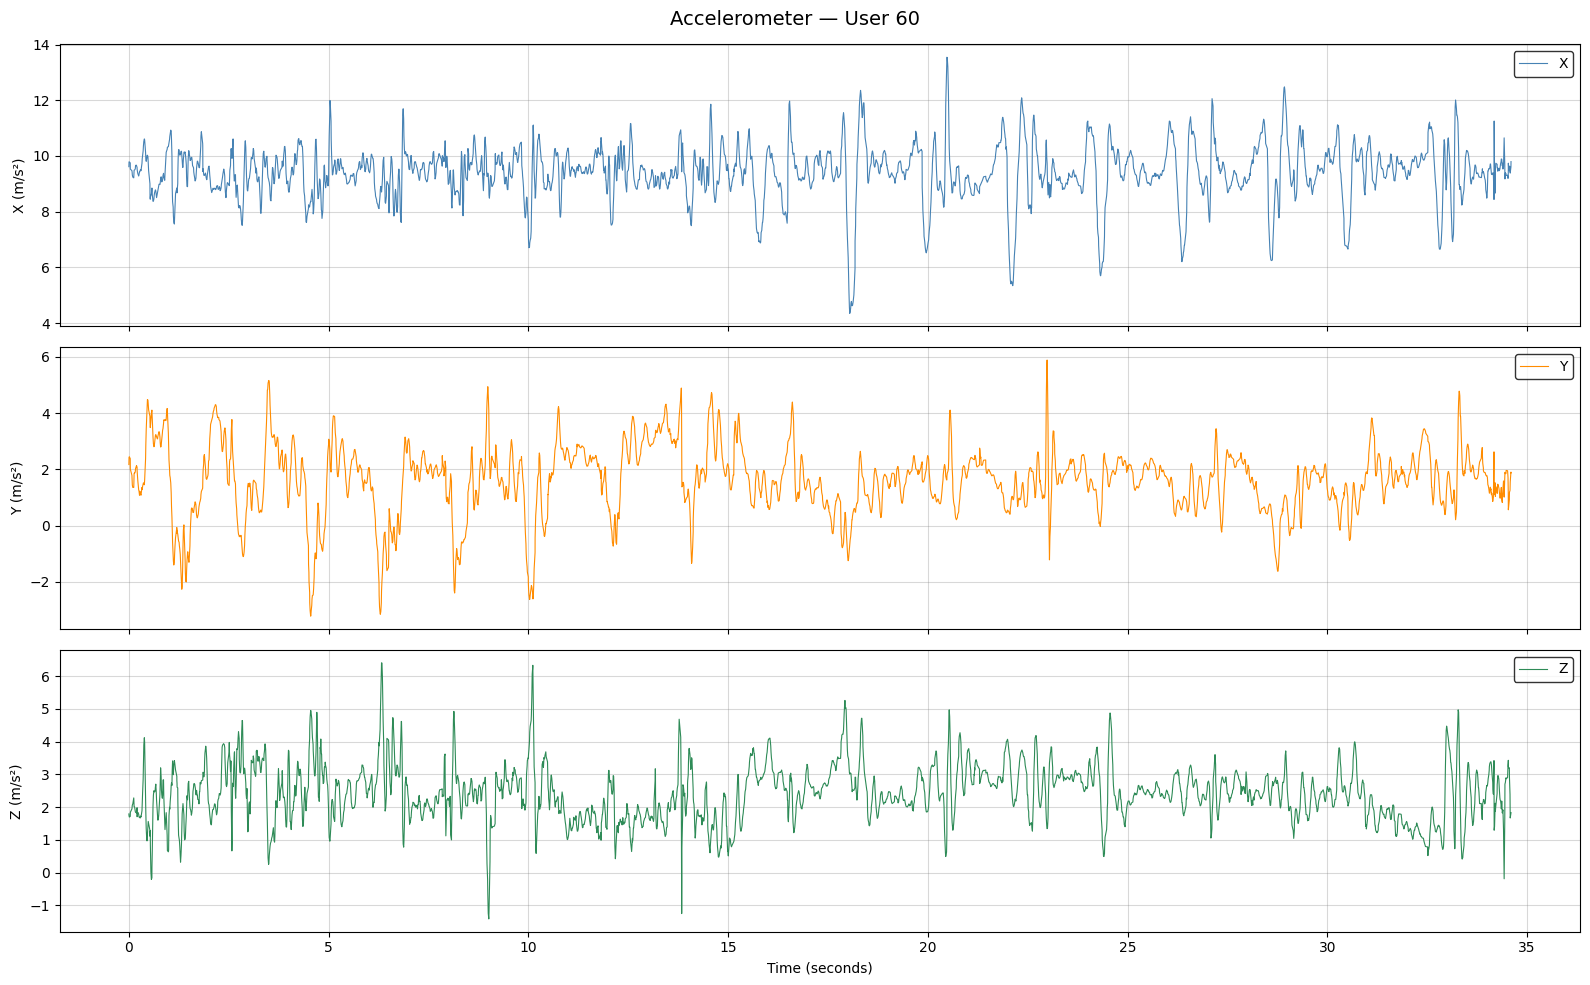

User chosen: 60


In [19]:
def plot_accelerometer_axes(user_id=None, save_path=None, base_path=None):
    """
    Plots the raw x, y, z axes of the accelerometer for a given user.
    If user_id is None, picks one at random.
    If base_path is None, uses the project root derived from this notebook's location.
    Returns the chosen user_id.
    """
    if base_path is None:
        base_path = os.path.join(os.getcwd(), 'data')

    if user_id is None:
        user_id = random.randint(1, samples)

    accel_file = os.path.join(base_path, str(user_id), 'accelerometer.txt')
    df = pd.read_csv(accel_file, sep='\t')

    # Convert timestamp to seconds relative to start
    t = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0

    with plt.rc_context({
        'text.color':        'black',
        'axes.labelcolor':   'black',
        'xtick.color':       'black',
        'ytick.color':       'black',
        'axes.edgecolor':    'black',
    }):
        fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True, facecolor='white')
        fig.suptitle(f'Accelerometer — User {user_id}', fontsize=14, color='black')

        for ax, col, color in zip(axes, ['x', 'y', 'z'], ['steelblue', 'darkorange', 'seagreen']):
            ax.set_facecolor('white')
            ax.plot(t, df[col], color=color, linewidth=0.8, label=col.upper())
            ax.set_ylabel(f'{col.upper()} (m/s²)', color='black')
            ax.legend(loc='upper right', facecolor='white', edgecolor='black', labelcolor='black')
            ax.grid(True, alpha=0.3, color='gray')

        axes[-1].set_xlabel('Time (seconds)', color='black')
        plt.tight_layout()

        if save_path:
            output_dir = os.path.dirname(save_path)
            if output_dir:
                os.makedirs(output_dir, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
            print(f"Image saved on: {os.path.abspath(save_path)}")

        plt.show()

    print(f"User chosen: {user_id}")
    return user_id


chosen_user = plot_accelerometer_axes(
    user_id=60,
    save_path=os.path.join(os.getcwd(), 'output', 'accelerometer_axes.png')
)


Sample User Characteristics:
User Id: 127
User Age: 34


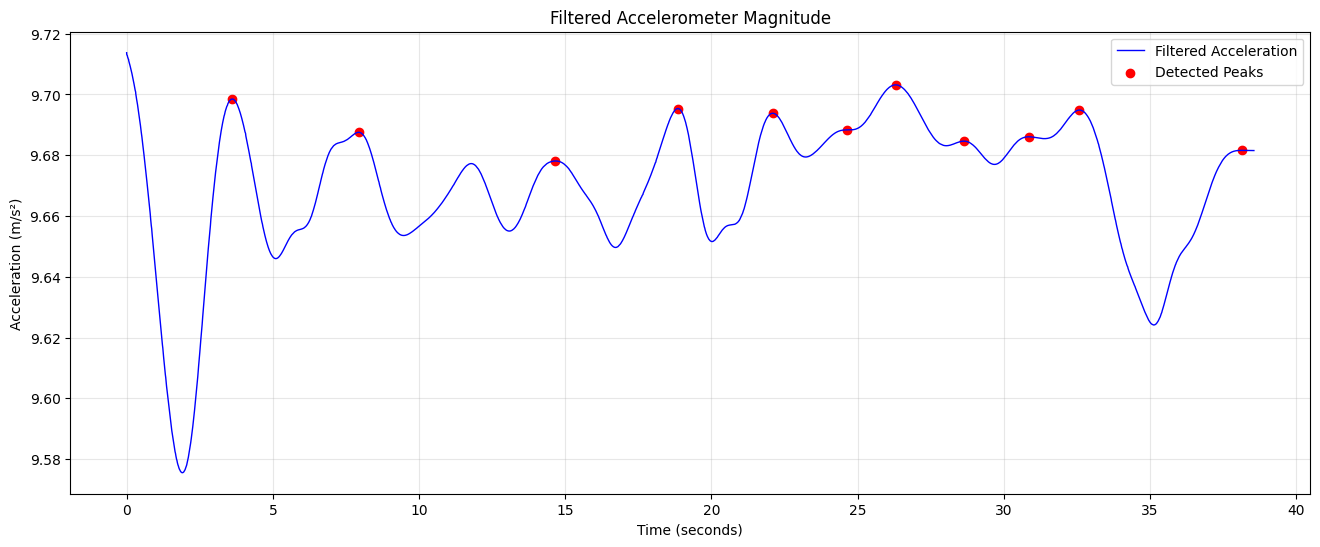

In [20]:
from helpers import prepare_accelerometer_data, detect_peaks, compute_step_metrics

### read all files for random sample and print info
a = random.randint(1,samples)
sample_path = os.path.join(data_path,str(a))
json_path = os.path.join(sample_path,'user_data.json')
#read data and visualize
with open(json_path, 'r', encoding= 'utf-8') as f:
    sample_data =  json.load(f)
    user_id = sample_data['user_id']
    user_age = sample_data['age']
    user_weight = sample_data['weight_kg']
    user_height = sample_data['height_cm']
    user_gender = sample_data['gender']
    phone_location = sample_data['phone_location']
    high_height_cm = sample_data['high_height_cm']
    print("Sample User Characteristics:")
    print("User Id:",user_id)
    print("User Age:",user_age)

    data_values={}
    accel_file = sample_path + '/' + 'accelerometer.txt'
    with open(accel_file, 'r') as f:
        accel_data = f.readlines()
        data_values['accelerometer'] = []
        for time_instant in accel_data[1:]:
            time_instant = time_instant.split()
            data_values['accelerometer'] = data_values['accelerometer'] + \
                    [[eval(time_instant[0]), [eval(component) for component in time_instant[1:]]]]
        ### Accelerometer
        accel_data = prepare_accelerometer_data(data_values)
        peaks = detect_peaks(accel_data)
        plot_accelerometer(accel_data, peaks)
        metrics = compute_step_metrics(accel_data, peaks)

# Classification Gender

In [21]:
genderfile_csv = os.path.join('./', 'results.csv')
df_gender = pd.read_csv(genderfile_csv, encoding='utf-8')
df_gender.drop('Sample', inplace=True, axis=1)
df_gender.drop('User ID', inplace=True, axis=1)

summary = df_gender.describe()

gender_counts = df_gender['Gender'].value_counts()

In [22]:
df_gender

,Gender,Age,Number of Repetitions,Total Time (s),Mean Time Between Repetitions (s),Mean Force (N),Mean Power (W)
0,Female,25,21,26.461,1.1910,553.1202,7.096140e+04
1,Male,27,4,29.131,6.0813,811.7685,1.118670e+05
2,Female,25,121,30.883,0.2510,543.4402,8.156687e+04
3,Female,28,6,29.380,4.6142,551.1127,7.851129e+04
4,Female,26,20,28.729,1.4127,550.7713,7.635418e+04
...,...,...,...,...,...,...,...
198,Male,29,6,31.049,0.3016,872.1007,1.313375e+05
199,Female,28,14,55.405,3.5451,5330.4166,1.414704e+06
200,Female,26,23,29.722,1.2435,552.8863,7.965886e+04
201,Female,51,29,50.222,1.5891,676.1828,1.639198e+05


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn

train, test = train_test_split(df_gender, test_size=0.3)

X_train = train.iloc[:, 1:]
y_train = train.iloc[:, 0]
X_test = test.iloc[:, 1:]
y_test = test.iloc[:, 0]

#Scale the data
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Classifier comparison


........ Score and Classification Report for Nearest Neighbors .............

              precision    recall  f1-score   support

      Female       0.76      0.98      0.85        42
        Male       0.86      0.32      0.46        19

    accuracy                           0.77        61
   macro avg       0.81      0.65      0.66        61
weighted avg       0.79      0.77      0.73        61



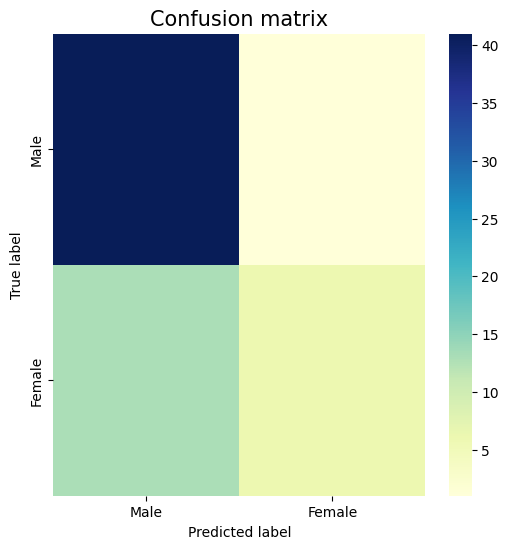


........ Score and Classification Report for Linear SVM .............

              precision    recall  f1-score   support

      Female       0.69      1.00      0.82        42
        Male       0.00      0.00      0.00        19

    accuracy                           0.69        61
   macro avg       0.34      0.50      0.41        61
weighted avg       0.47      0.69      0.56        61



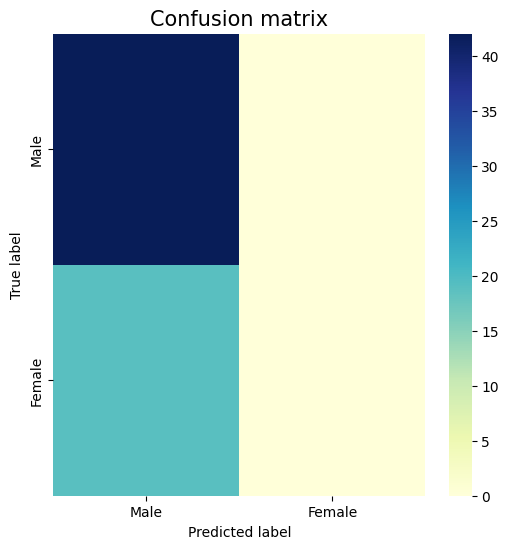


........ Score and Classification Report for RBF SVM .............

              precision    recall  f1-score   support

      Female       0.76      1.00      0.87        42
        Male       1.00      0.32      0.48        19

    accuracy                           0.79        61
   macro avg       0.88      0.66      0.67        61
weighted avg       0.84      0.79      0.75        61



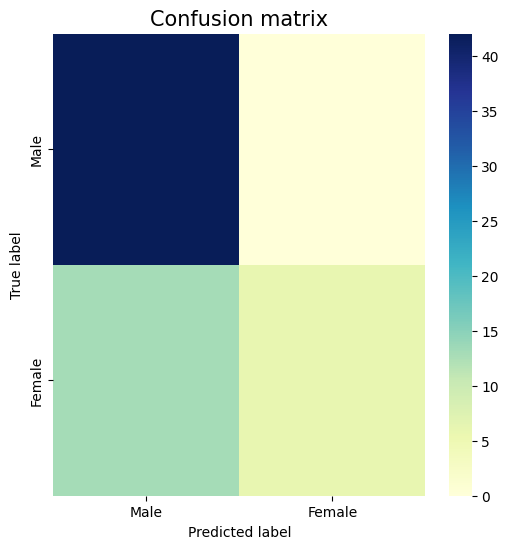


........ Score and Classification Report for Decision Tree .............

              precision    recall  f1-score   support

      Female       1.00      1.00      1.00        42
        Male       1.00      1.00      1.00        19

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



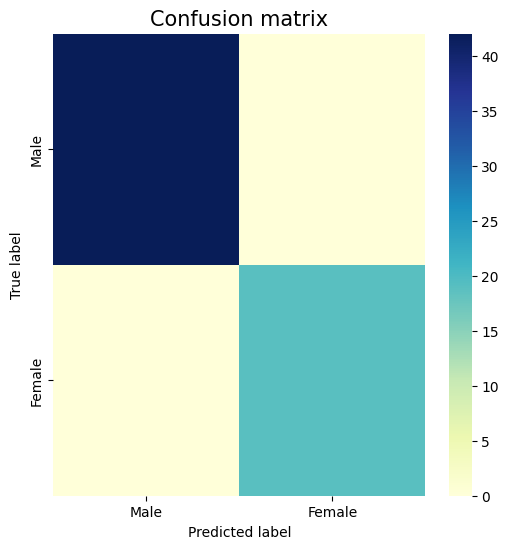


........ Score and Classification Report for Random Forest .............

              precision    recall  f1-score   support

      Female       0.88      1.00      0.93        42
        Male       1.00      0.68      0.81        19

    accuracy                           0.90        61
   macro avg       0.94      0.84      0.87        61
weighted avg       0.91      0.90      0.90        61



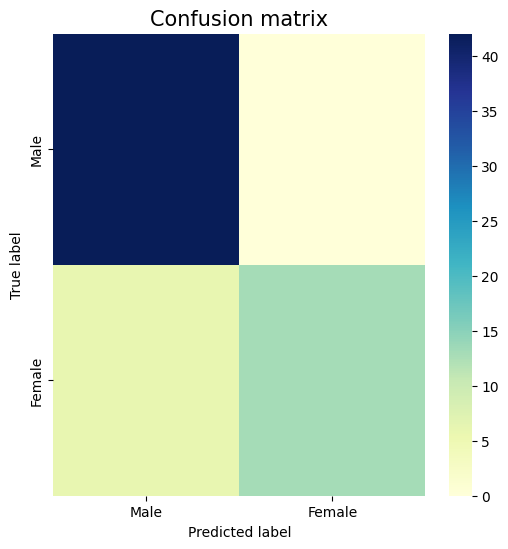


........ Score and Classification Report for Neural Net .............

              precision    recall  f1-score   support

      Female       0.81      1.00      0.89        42
        Male       1.00      0.47      0.64        19

    accuracy                           0.84        61
   macro avg       0.90      0.74      0.77        61
weighted avg       0.87      0.84      0.82        61



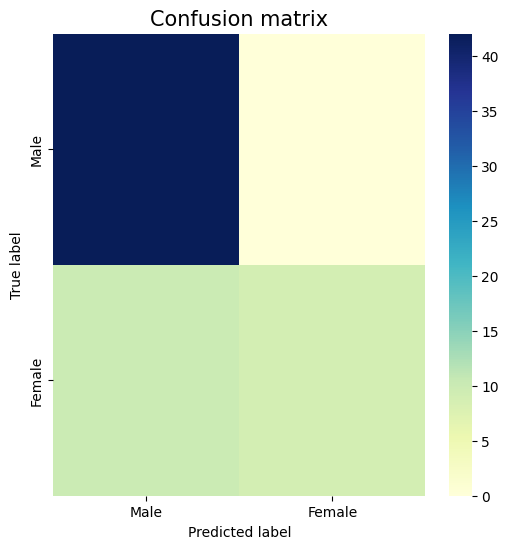


........ Score and Classification Report for AdaBoost .............

              precision    recall  f1-score   support

      Female       1.00      1.00      1.00        42
        Male       1.00      1.00      1.00        19

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



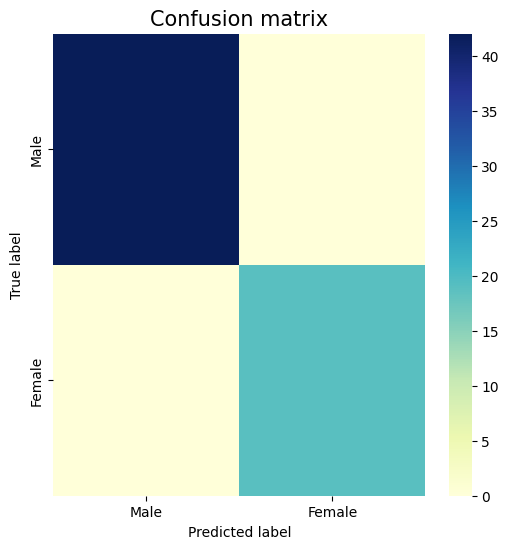


........ Score and Classification Report for Naive Bayes .............

              precision    recall  f1-score   support

      Female       0.85      0.26      0.40        42
        Male       0.35      0.89      0.51        19

    accuracy                           0.46        61
   macro avg       0.60      0.58      0.45        61
weighted avg       0.69      0.46      0.43        61



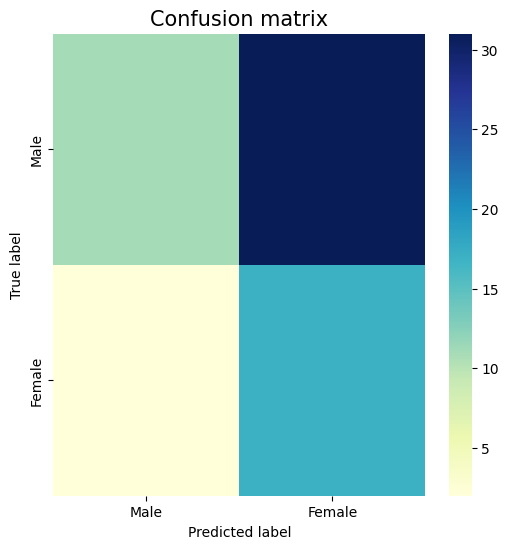

|       Classifier        |          Score          |
------------------------------------------------------
|    Nearest Neighbors    |   0.7704918032786885    |
|       Linear SVM        |   0.6885245901639344    |
|         RBF SVM         |   0.7868852459016393    |
|      Decision Tree      |           1.0           |
|      Random Forest      |   0.9016393442622951    |
|       Neural Net        |   0.8360655737704918    |
|        AdaBoost         |           1.0           |
|       Naive Bayes       |   0.45901639344262296   |


In [24]:
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

import warnings

warnings.filterwarnings('ignore')  # setting ignore as a parameter

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(gamma=2, C=1),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
]
alllabels = ['Male', 'Female']
scores = []
for name, clf in zip(names, classifiers):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    score = clf.score(X_test, y_test)
    print('\n........ Score and Classification Report for {0} .............\n'.format(name))
    scores.append(score)
    print(classification_report(y_test, y_pred))

    cfm1 = confusion_matrix(y_test, y_pred)
    fig = plt.subplots(figsize=(6, 6))
    seaborn.heatmap(cfm1, xticklabels=alllabels, yticklabels=alllabels, cmap='YlGnBu')
    plt.title('Confusion matrix', fontsize=15)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
print("|{0:^25}|{1:^25}|".format("Classifier", "Score"))
print("------------------------------------------------------")
for name, score in zip(names, scores):
    print("|{0:^25}|{1:^25}|".format(name, score))